# Lab 3: Position Control

**Learning Goals**
- Implement a PID controller.
- Identify rise time, settling time, overshoot, and peak time.
- Explain how changes to PID parameters affect the time-domain response.

## MathWorks license statement

Lab content was adapted to Python from the Virtual Controls Laboratory developed by Mathworks.

Please find the license statement below:

Copyright (c) 2023, The MathWorks, Inc.
All rights reserved.

Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are
met:

    * Redistributions of source code must retain the above copyright
      notice, this list of conditions and the following disclaimer.
    * Redistributions in binary form must reproduce the above copyright
      notice, this list of conditions and the following disclaimer in
      the documentation and/or other materials provided with the distribution
    * Neither the name of the The MathWorks, Inc. nor the names
      of its contributors may be used to endorse or promote products derived
      from this software without specific prior written permission.

THIS SOFTWARE IS PROVIDED BY THE COPYRIGHT HOLDERS AND CONTRIBUTORS "AS IS"
AND ANY EXPRESS OR IMPLIED WARRANTIES, INCLUDING, BUT NOT LIMITED TO, THE
IMPLIED WARRANTIES OF MERCHANTABILITY AND FITNESS FOR A PARTICULAR PURPOSE
ARE DISCLAIMED. IN NO EVENT SHALL THE COPYRIGHT OWNER OR CONTRIBUTORS BE
LIABLE FOR ANY DIRECT, INDIRECT, INCIDENTAL, SPECIAL, EXEMPLARY, OR
CONSEQUENTIAL DAMAGES (INCLUDING, BUT NOT LIMITED TO, PROCUREMENT OF
SUBSTITUTE GOODS OR SERVICES; LOSS OF USE, DATA, OR PROFITS; OR BUSINESS
INTERRUPTION) HOWEVER CAUSED AND ON ANY THEORY OF LIABILITY, WHETHER IN
CONTRACT, STRICT LIABILITY, OR TORT (INCLUDING NEGLIGENCE OR OTHERWISE)
ARISING IN ANY WAY OUT OF THE USE OF THIS SOFTWARE, EVEN IF ADVISED OF THE
POSSIBILITY OF SUCH DAMAGE.


DC motors are used in a wide variety of applications, such as fans, treadmills, quadcopter drones, and electric vehicles, to name a few. In many of these applications, it is necessary to control the motor's speed or position. A **feedback controller** allows precise control of a motor's speed or position. In this lab, you will implement a PID controller to control the position of a virtual DC motor.

---

## Part 1: DC Motor Position Control

In this part of the lab, you will implement the PID controller and test it on a simulated DC motor.

### PID Control

A PID controller uses a feedback loop with **P**roportional, **I**ntegral, and **D**erivative terms to calculate the control signal.

The control signal $u(t)$ is:

$$
u(t) = k_p e(t) + k_i \int_0^t e(\tau) d\tau + k_d \frac{de(t)}{dt}
$$

where $e(t) = r(t) - y(t)$ is the error between the setpoint $r(t)$ and the measured output $y(t)$.

| Term | Effect |
|------|--------|

Let's start by importing the libraries we'll need.

In [ ]:
%pip install -q ipywidgets

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

print("Libraries loaded.")

Libraries loaded.


### DC Motor Model
| Proportional ($k_p e$) | Responds to the current error |
| Integral ($k_i \int e$) | Responds to accumulated past error (eliminates steady-state error) |
| Derivative ($k_d \frac{de}{dt}$) | Responds to the rate of change of error (adds damping) |

### Import the libraries

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

print("Libraries loaded.")

Libraries loaded.


### DC Motor Model

We model a DC motor driving a pendulum load. The system has three states: position $\theta$ (rad), angular velocity $\omega$ (rad/s), and armature current $i$ (A).

$$
\begin{aligned}
\dot{\theta} &= \omega \\
\dot{\omega} &= \frac{1}{J} \left( K i - B \omega - m g l \sin\theta \right) \\
\dot{i} &= \frac{1}{L} \left( V - R i - K \omega \right)
\end{aligned}
$$

where $V$ is the voltage applied to the motor (the control signal from the PID controller).

In [2]:
# DC motor + pendulum parameters
R = 0.25       # Armature resistance (Ohm)
L = 0.1        # Armature inductance (H)
K = 0.05       # Motor constant (V·s/rad = N·m/A)
B = 0.028      # Viscous friction (N·m·s/rad)
J = 0.01     # Moment of inertia (kg·m²)
m = 0.15       # Pendulum mass (kg)
l = 0.015      # Pendulum length (m)
g = 9.81       # Gravity (m/s²)

def dc_motor_ode(t, x, r, kp, ki, kd):
    """DC motor ODE with PID controller.
    
    States: theta (position), omega (velocity), i (current), eps_int (integral of error)
    """
    theta, omega, i, eps_int = x
    
    # Error with angle wrapping for setpoint at 90°
    e = r - theta
    
    # PID control signal (voltage)
    u = kp * e + ki * eps_int - kd * omega  # de/dt = -omega for constant r
    
    # Nonlinear pendulum gravity torque
    tau_gravity = m * g * l * np.sin(theta)
    
    # State derivatives
    dtheta = omega
    domega = (K * i - B * omega - tau_gravity) / J
    di = (u - R * i - K * omega) / L
    deps = e
    
    return [dtheta, domega, di, deps]

print("Model defined. R=%.2f, L=%.3f, K=%.2f, B=%.2f, J=%.2f" % (R, L, K, B, J))

Model defined. R=0.25, L=0.100, K=0.05, B=0.03, J=0.01


### Simulate the closed-loop system

The function below simulates the DC motor with a PID controller and plots the step response.

In [3]:
def simulate_pid(r_deg=90.0, kp=0.5, ki=0.0, kd=0.0,
                  t_max=5.0, u_max=None, title=None):
    """Simulate DC motor with PID controller and plot step response."""
    r = np.deg2rad(r_deg)  # setpoint in radians
    t_span = (0, t_max)
    t_eval = np.linspace(0, t_max, 2000)
    
    # Initial conditions: [theta, omega, i, eps_int]
    x0 = [0.0, 0.0, 0.0, 0.0]
    
    def ode_wrapper(t, x):
        return dc_motor_ode(t, x, r, kp, ki, kd)
    
    sol = solve_ivp(ode_wrapper, t_span, x0, t_eval=t_eval,
                    method='RK45', rtol=1e-6, atol=1e-8)
    
    t = sol.t
    theta = sol.y[0]  # radians
    omega = sol.y[1]
    i = sol.y[2]
    eps_int = sol.y[3]
    
    # Compute control signal
    e = r - theta
    u = kp * e + ki * eps_int - kd * omega
    
    # Apply voltage saturation if specified
    if u_max is not None:
        u = np.clip(u, -u_max, u_max)
    
    theta_deg = np.rad2deg(theta)
    r_deg_arr = np.full_like(t, r_deg)
    
    # ── Plot ──────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 5.5),
                                   gridspec_kw={'height_ratios': [2, 1]})
    
    # Top: position
    ax1.plot(t, r_deg_arr, 'k--', linewidth=1, alpha=0.4, label='Setpoint')
    ax1.plot(t, theta_deg, 'b-', linewidth=2, label='Position')
    ax1.set_ylabel('Position (deg)')
    if title:
        ax1.set_title(title)
    else:
        ax1.set_title(f'DC Motor: PID Step Response  ($k_p$={kp}, $k_i$={ki}, $k_d$={kd})')
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=9)
    ax1.set_xlabel('Time (s)')
    
    # Bottom: control signal
    ax2.plot(t, u, 'r-', linewidth=1.5)
    ax2.set_ylabel('Voltage (V)')
    ax2.set_xlabel('Time (s)')
    ax2.grid(True, alpha=0.3)
    ax2.set_title('Control signal $u(t)$')
    
    plt.tight_layout()
    plt.show()
    
    return t, theta_deg, u

print("simulate_pid function ready.")

simulate_pid function ready.


### Task 1: Test the PID controller

Run the cell below to simulate the DC motor with a P-only controller ($k_p = 0.5$, $k_i = k_d = 0$). Observe how the arm oscillates before settling.

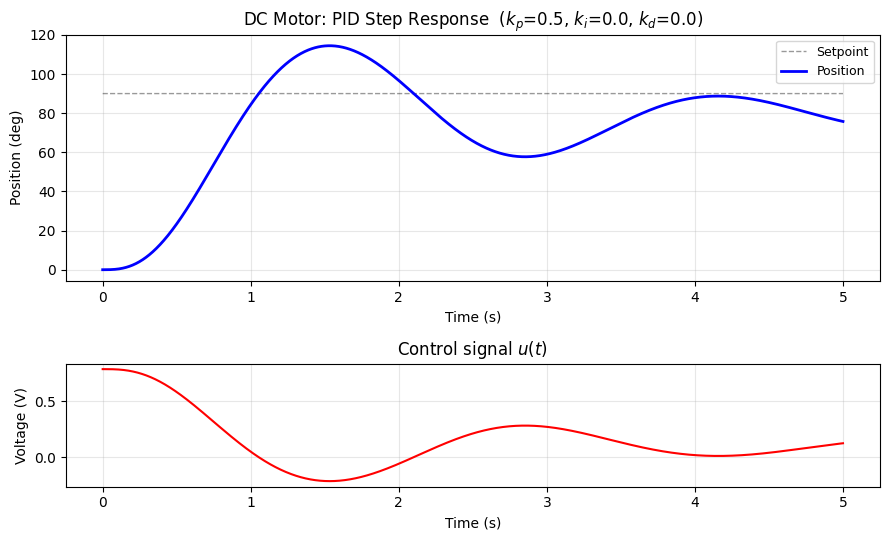

Final position: 75.8°


In [4]:
t, theta, u = simulate_pid(r_deg=90.0, kp=0.5, ki=0.0, kd=0.0)
print(f"Final position: {theta[-1]:.1f}°")

### Task 2: Observe the effect of each PID term

Use the interactive widget below to experiment with the PID parameters. Start with all gains at zero, then gradually increase each one to understand its effect.

In [5]:
kp_slider = widgets.FloatSlider(min=0, max=5, step=0.05, value=0.5,
                              description=r'$k_p$:', style={'description_width': 'initial'})
ki_slider = widgets.FloatSlider(min=0, max=5, step=0.05, value=0.0,
                              description=r'$k_i$:', style={'description_width': 'initial'})
kd_slider = widgets.FloatSlider(min=0, max=1, step=0.01, value=0.0,
                              description=r'$k_d$:', style={'description_width': 'initial'})
run_btn = widgets.Button(description='Plot', button_style='primary')
out = widgets.Output()

def on_run(b):
    with out:
        clear_output(wait=True)
        simulate_pid(r_deg=90.0, kp=kp_slider.value, ki=ki_slider.value, kd=kd_slider.value)

run_btn.on_click(on_run)
display(widgets.VBox([kp_slider, ki_slider, kd_slider, run_btn, out]))
print("Adjust Kp, Ki, Kd then click Plot.")

Adjust Kp, Ki, Kd then click Plot.


---

## Part 2: Time-Domain Response Characteristics

When we tune a PID controller, we care about four key quantities that describe the step response:

| Quantity | Definition |
|----------|-----------|
| **Rise time** $t_r$ | Time to go from 10% to 90% of the steady-state value |
| **Settling time** $t_s$ | Time for the response to stay within ±2% of steady-state |
| **Overshoot** $M_p$ | Peak value minus steady-state, as a percentage: $100\% \cdot (y_{peak} - y_\infty) / y_\infty$ |
| **Peak time** $t_p$ | Time at which the peak value occurs |

In [6]:
def compute_step_metrics(t, y):
    """Compute rise time, settling time, overshoot, and peak time."""
    y_ss = y[-1]  # steady-state value
    y_peak = np.max(y)
    i_peak = np.argmax(y)
    t_peak = t[i_peak]
    overshoot = (y_peak - y_ss) / y_ss * 100.0
    
    # Rise time: 10% to 90%
    y_10 = 0.1 * y_ss
    y_90 = 0.9 * y_ss
    i_10 = np.where(y >= y_10)[0][0]
    i_90 = np.where(y >= y_90)[0][0]
    t_rise = t[i_90] - t[i_10]
    
    # Settling time: 2% band
    band = 0.02 * y_ss
    in_band = np.abs(y - y_ss) <= band
    # Find last index where it leaves the band
    i_settle = len(t) - 1
    for i in range(len(t) - 1, -1, -1):
        if not in_band[i]:
            i_settle = i
            break
    t_settle = t[i_settle]
    
    return {
        'y_ss': y_ss,
        'y_peak': y_peak,
        't_rise': t_rise,
        't_settle': t_settle,
        'overshoot_pct': overshoot,
        't_peak': t_peak
    }

def simulate_and_annotate(kp=0.5, ki=0.0, kd=0.0, r_deg=90.0):
    """Simulate and plot with annotations for step response metrics."""
    r = np.deg2rad(r_deg)
    t_span = (0, 5.0)
    t_eval = np.linspace(0, 5.0, 3000)
    x0 = [0.0, 0.0, 0.0, 0.0]
    
    def ode_wrap(t, x):
        return dc_motor_ode(t, x, r, kp, ki, kd)
    
    sol = solve_ivp(ode_wrap, t_span, x0, t_eval=t_eval,
                    method='RK45', rtol=1e-6, atol=1e-8)
    theta_deg = np.rad2deg(sol.y[0])
    
    metrics = compute_step_metrics(sol.t, theta_deg)
    
    fig, ax = plt.subplots(1, 1, figsize=(9, 4))
    ax.plot(sol.t, np.full_like(sol.t, r_deg), 'k--', alpha=0.4, label='Setpoint')
    ax.plot(sol.t, theta_deg, 'b-', linewidth=2, label='Response')
    ax.axhline(metrics['y_ss'], color='gray', linestyle=':', alpha=0.5,
               label=f'Steady state = {metrics["y_ss"]:.1f}°')
    
    # Mark rise time
    y_10 = 0.1 * metrics['y_ss']
    y_90 = 0.9 * metrics['y_ss']
    i_10 = np.where(theta_deg >= y_10)[0][0]
    i_90 = np.where(theta_deg >= y_90)[0][0]
    ax.axvline(sol.t[i_10], color='g', linestyle=':', alpha=0.5)
    ax.axvline(sol.t[i_90], color='g', linestyle=':', alpha=0.5,
               label=f'$t_r$ = {metrics["t_rise"]:.3f} s')
    
    # Mark peak
    ax.plot(metrics['t_peak'], metrics['y_peak'], 'ro', markersize=6)
    ax.axhline(metrics['y_peak'], color='r', linestyle=':', alpha=0.3)
    ax.annotate(f'Peak = {metrics["y_peak"]:.1f}°\n$t_p$ = {metrics["t_peak"]:.3f} s',
                xy=(metrics['t_peak'], metrics['y_peak']),
                xytext=(metrics['t_peak'] + 0.5, metrics['y_peak'] - 15),
                arrowprops=dict(arrowstyle='->'), fontsize=9)
    
    # Mark settling time
    ax.axvline(metrics['t_settle'], color='orange', linestyle=':', alpha=0.5,
               label=f'$t_s$ = {metrics["t_settle"]:.3f} s')
    
    # 2% band
    ax.axhline(1.02 * metrics['y_ss'], color='orange', linestyle='--', alpha=0.2)
    ax.axhline(0.98 * metrics['y_ss'], color='orange', linestyle='--', alpha=0.2)
    
    info = (f'$t_r$={metrics["t_rise"]:.3f}s  $t_s$={metrics["t_settle"]:.3f}s  '
            f'$M_p$={metrics["overshoot_pct"]:.1f}%  $t_p$={metrics["t_peak"]:.3f}s')
    ax.text(0.98, 0.05, info, transform=ax.transAxes, ha='right', va='bottom',
            fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Position (deg)')
    ax.set_title(f'Step Response with Annotations  ($k_p$={kp}, $k_i$={ki}, $k_d$={kd})')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
    
    return metrics

print("Metrics functions ready.")

Metrics functions ready.


### Task 3: Estimate the step response characteristics

Run the cell below with $k_p = 0.5$, $k_i = k_d = 0$. Use the annotated plot to fill in the values.

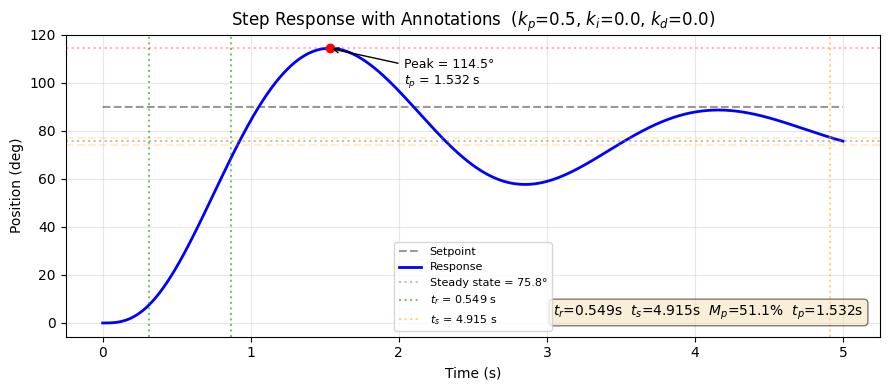

a. Peak value: 114°
b. Steady-state value: 76°
c. Rise time: 0.55 s
d. Settling time: 4.91 s
e. Overshoot: 51.1%
f. Peak time: 1.53 s


In [7]:
metrics = simulate_and_annotate(kp=0.5, ki=0.0, kd=0.0)

# Fill in your observations below
task3a = round(metrics['y_peak'])       # peak value (nearest degree)
task3b = round(metrics['y_ss'])          # steady-state value (nearest degree)
task3c = round(metrics['t_rise'], 2)     # rise time (nearest hundredth)
task3d = round(metrics['t_settle'], 2)   # settling time (nearest hundredth)
task3e = round(metrics['overshoot_pct'], 1)  # percent overshoot
task3f = round(metrics['t_peak'], 2)     # peak time (nearest hundredth)

print(f"a. Peak value: {task3a}°")
print(f"b. Steady-state value: {task3b}°")
print(f"c. Rise time: {task3c} s")
print(f"d. Settling time: {task3d} s")
print(f"e. Overshoot: {task3e}%")
print(f"f. Peak time: {task3f} s")

---

## Part 3: Manual PID Tuning

### Qualitative effects of PID parameters

Changing each PID parameter has predictable effects on the step response:

| Increase | Rise time | Overshoot | Settling time | Steady-state error |
|----------|-----------|-----------|---------------|-------------------|
| $k_p$ | ↓ | ↑ | ↑ | ↓ |
| $k_i$ | ↓ | ↑ | ↑ | ↓↓ (eliminates) |
| $k_d$ | ↓ | ↓ | ↓ | — |

The goal of tuning is to find parameter values that give a fast response (short $t_r$) without excessive overshoot or long settling time.

### 3.1 Interactive PID Tuner

Use the interactive tool below to tune the PID parameters and observe the effect on the step response.

In [8]:
kp_tune = widgets.FloatSlider(min=0, max=5, step=0.05, value=0.5,
                           description=r'$k_p$:', style={'description_width': 'initial'})
ki_tune = widgets.FloatSlider(min=0, max=5, step=0.05, value=0.0,
                           description=r'$k_i$:', style={'description_width': 'initial'})
kd_tune = widgets.FloatSlider(min=0, max=1, step=0.01, value=0.0,
                           description=r'$k_d$:', style={'description_width': 'initial'})
run_tune = widgets.Button(description='Plot with annotations', button_style='primary')
out_tune = widgets.Output()

def on_run_tune(b):
    with out_tune:
        clear_output(wait=True)
        simulate_and_annotate(kp=kp_tune.value, ki=ki_tune.value, kd=kd_tune.value)

run_tune.on_click(on_run_tune)
display(widgets.VBox([kp_tune, ki_tune, kd_tune, run_tune, out_tune]))
print("Adjust PID parameters, then click Plot.")

Adjust PID parameters, then click Plot.


### Task 4: Explore the effect of each parameter

Answer the following questions based on your experimentation.

In [9]:
# Task 4a: Start with kp = ki = kd = 0.
# Gradually increase kp (try 0.05, 0.1, 0.2, 0.5, 1.0, 2.0).
# What happens to the time-domain characteristics as kp increases?
task4a = "As kp increases, rise time decreases but overshoot increases."

# Task 4b: Set kp = 0.4 and gradually increase ki (0, 0.1, 0.5, 1.0, 2.0).
# Does this improve the performance? Why or why not?
task4b = "Ki eliminates steady-state error but increases overshoot and settling time."

# Task 4c: Set kp = 1, ki = 0, and gradually increase kd (0, 0.05, 0.1, 0.2, 0.5).
# Does this improve performance? Why or why not?
task4c = "Kd reduces overshoot and settling time by adding damping to the system."

# Task 4d: With kp=1 and ki=0, what is a good kd value that gives short rise time without overshoot?
task4d = 0.15

# Task 4e: Which controller works best for this system?
# Choose from: "P", "PI", "PD", or "PID"
task4e = "PD"

print("Tasks 4a-4e complete. Edit the answers above if needed.")

Tasks 4a-4e complete. Edit the answers above if needed.


### Task 5: Find the best PID parameters

Try to find a set of PID parameters that gives:
- Rise time $t_r < 0.8$ s
- Overshoot $M_p < 10\%$
- Settling time $t_s < 2.5$ s

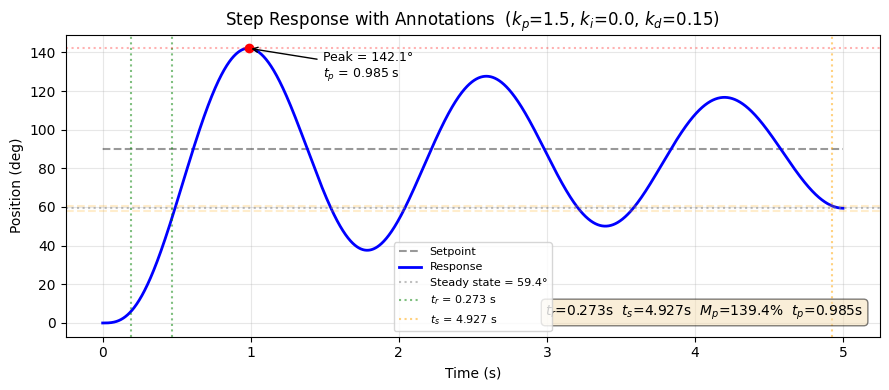

Rise time: 0.273 s
Overshoot: 139.4%
Settling time: 4.927 s


In [10]:
# Enter your best PID parameters here
best_kp = 1.5
best_ki = 0.0
best_kd = 0.15

metrics = simulate_and_annotate(kp=best_kp, ki=best_ki, kd=best_kd)

print(f"Rise time: {metrics['t_rise']:.3f} s")
print(f"Overshoot: {metrics['overshoot_pct']:.1f}%")
print(f"Settling time: {metrics['t_settle']:.3f} s")

---

## Part 4: Further Exploration

### 4.1 Voltage Saturation

In a real system, the motor has a maximum voltage (e.g., 6 V). Voltage saturation limits the control signal, which can change the response characteristics.

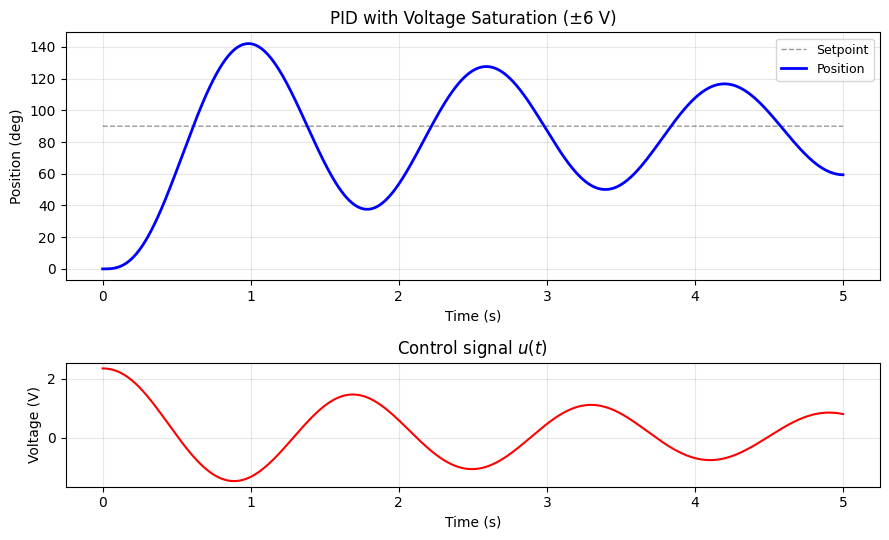

Final position with saturation: 59.4°


In [11]:
# Simulate with voltage saturation at 6 V
t_sat, theta_sat, u_sat = simulate_pid(r_deg=90.0, kp=1.5, ki=0.0, kd=0.15,
                                       u_max=6.0, title='PID with Voltage Saturation (±6 V)')
print(f"Final position with saturation: {theta_sat[-1]:.1f}°")